# Simulations and testing

- Simulations are based on the `simulation_master.py` module. 
- All simulations are versions of AR(1) models.
- This is notebook is a guide to simulate a series, calculate GSADF, SADF and ADF test statistics, simulate critical values, compute and plot BSADF test and do the Monte carlo simulation study. 
- This notebook focuses on a simple random walk. Copy and paste the notebook and tweak the bubble process to get another simulation and the above calculations for it. 

First we import relevant libraries and the module file.

In [1]:
# to run R code
%load_ext rpy2.ipython

# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
import sys
import importlib

# add path to the module
sys.path.append(os.path.abspath(".."))

# import functions
from simulation import simulation_master

# reload functions
importlib.reload(simulation_master)

<module 'simulation.simulation_master' from '/Users/erafh/Desktop/ku/bachelor/6. semester/ba/ba_repo/simulation/simulation_master.py'>

### Random walk with with drift - 3 bubbles (simulating dot-com, corona, and AI)

If we define bubble periods as:

- dot-com bubble: january 1995 -> october 2002
- covid bubble: april 2020 -> july 2021
- ai bubble: january 2023 -> december 2025

And the sample length as januar 1990 -> december 2025, then there are with monthly data: $(2025 - 1990 + 1)\cdot 12 = 432$ observations. Using the periods as above we get:

- dot-com bubble: 61 -> 154
- covid bubble: 364 -> 382
- ai bubble: 397 -> 432

### Late bubble example

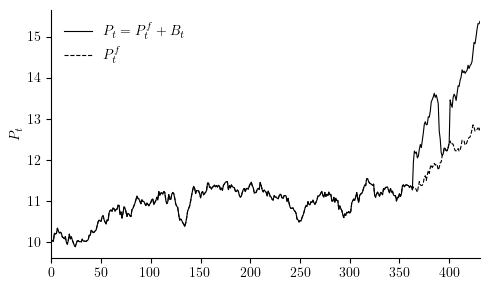

In [3]:
# simulate random walk with drift - late bubbles
T=432
Pf_latebubbles, B_latebubbles, P_latebubbles = simulation_master.simulate_price_with_bubbles(
    
    # Sample size
    T = T,
    
    # Fundamental component
    rho_f = 1.0,
    mu_f = 1/T,
    sigma_f = 0.08,
    Pf0 = 10.0,

    # Bubble component
    include_bubble = True,
    R = 0.04,
    sigma_b = 0.1,
    omega = 0.6,
    B0 = 0.0,

    # Covid
    # tau_s1 = 360, 
    # tau_e1 = 384,
    # B0_1 = 0.6,
    tau_s1 = 364, 
    tau_e1 = 389,
    B0_1 = 0.6,

    # AI
    tau_s2 = 401,
    tau_e2 = 432,
    B0_2 = 1.0,

    # Dot-Com
    # tau_s3=80,
    # tau_e3=130,
    # B0_3=0.3,

    # seed
    seed = 5,
)

# font
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# plot
plt.figure(figsize=(5, 3))
plt.plot(P_latebubbles.index, P_latebubbles.values, color='black', linewidth=0.8, ls='-', label=r'$P_t = P_t^f + B_t$')
plt.plot(Pf_latebubbles.index, Pf_latebubbles.values, color='black', linewidth=0.8, ls='--', label=r'$P_t^f$')
plt.ylabel(r'$P_t$')

# formatting
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))
# plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='upper left')
plt.xlim(P_latebubbles.index.min(), P_latebubbles.index.max())

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save and show
plt.savefig('plots/P_latebubbles.pdf')
P_latebubbles = P_latebubbles.rename('P_latebubbles')
P_latebubbles.to_csv('data/P_latebubbles.csv', index=False)
plt.show()

### 2. Next we use the exuber package from R, to apply BSADF and GSADF methods to the series, and download the series. 

In [4]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('data/P_latebubbles.csv') #../../data/simulated/timeseries/P_late_bubble.csv
y   <- ts(dat$P_latebubbles)     # change after $ to the column name
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/P_latebubbles_bsadf.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv, "results/P_latebubbles_cv.csv", row.names = FALSE)


── radf (minw = 41, lag = 0) ───────────────────────────────────────────────────

       id       adf      sadf     gsadf
  series1  2.069716  2.087103  2.548455

  gsadf_panel
     2.548455


── Monte Carlo (minw = 41, nrep = 2000) ────────────────────────────────────────

  sig          adf      sadf     gsadf
   90  -0.39620743  1.151958  1.940131
   95  -0.03740744  1.450801  2.165954
   99   0.63280779  2.039598  2.622547



### 3. Now we plot the BSADF stats with 95 and 99% critical values. 

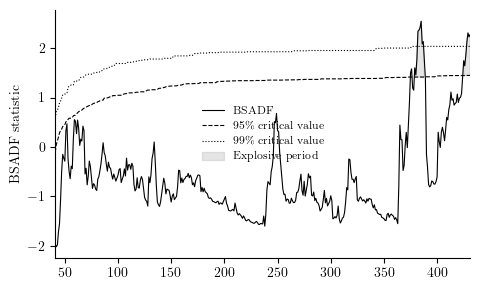

In [5]:
# font
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# data
bsadf_stat = pd.read_csv("results/P_latebubbles_bsadf.csv")
bsadf_cv   = pd.read_csv("results/P_latebubbles_cv.csv")
t = P_latebubbles.index[-len(bsadf_stat):]

# plot
plt.figure(figsize=(5, 3))
plt.plot(t, bsadf_stat["bsadf"], color='black', linewidth=0.8, ls='-', label='BSADF')
plt.plot(t, bsadf_cv["95%"], color='black', linewidth=0.8, ls='--', label=r'95\% critical value')
plt.plot(t, bsadf_cv["99%"], color='black', linewidth=0.8, ls=':', label=r'99\% critical value')

plt.fill_between(t, # optional shading of explosive periods for 95% cv
                 bsadf_stat["bsadf"],
                 bsadf_cv["95%"],
                 where=(bsadf_stat["bsadf"] > bsadf_cv["95%"]),
                 color='grey',
                 alpha=0.2,
                 label='Explosive period')

# labels
plt.ylabel('BSADF statistic')

# formatting
plt.tight_layout()
# plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, fontsize=8)

plt.xlim(t.min(), t.max())

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save
plt.savefig("plots/P_latebubbles_bsadf.pdf", bbox_inches="tight")
plt.show()

We do the same for the smaller period (301-432)

In [6]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('data/P_latebubbles.csv')

# Select only observations 301 -> 432
y_full <- dat$P_latebubbles
y      <- ts(y_full[301:432])
T      <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv
res$bsadf

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/P_latebubbles_bsadf_short.csv", row.names = FALSE)

# BSADF critical values
bsadf_cv <- as.data.frame(cv$bsadf_cv)
write.csv(bsadf_cv, "results/P_latebubbles_cv_short.csv", row.names = FALSE)


── radf (minw = 22, lag = 0) ───────────────────────────────────────────────────

       id        adf     sadf     gsadf
  series1  0.7238225  1.44025  1.797362

  gsadf_panel
     1.797362


── Monte Carlo (minw = 22, nrep = 2000) ────────────────────────────────────────

  sig         adf      sadf     gsadf
   90  -0.4496014  1.002152  1.771418
   95  -0.1377478  1.330626  2.052327
   99   0.6666404  1.930828  2.631734



And plot the shorter BSADF sample

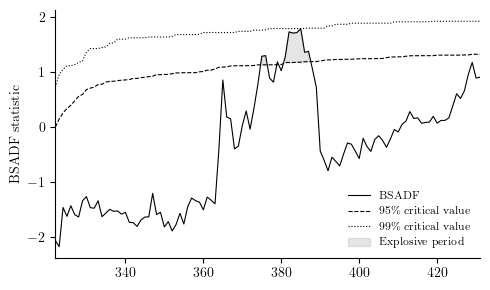

In [7]:
# font
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# data
bsadf_stat = pd.read_csv("results/P_latebubbles_bsadf_short.csv")
bsadf_cv   = pd.read_csv("results/P_latebubbles_cv_short.csv")
t = P_latebubbles.index[-len(bsadf_stat):]

# plot
plt.figure(figsize=(5, 3))
plt.plot(t, bsadf_stat["bsadf"], color='black', linewidth=0.8, ls='-', label='BSADF')
plt.plot(t, bsadf_cv["95%"], color='black', linewidth=0.8, ls='--', label=r'95\% critical value')
plt.plot(t, bsadf_cv["99%"], color='black', linewidth=0.8, ls=':', label=r'99\% critical value')

plt.fill_between(t, # optional shading of explosive periods for 95% cv
                 bsadf_stat["bsadf"],
                 bsadf_cv["95%"],
                 where=(bsadf_stat["bsadf"] > bsadf_cv["95%"]),
                 color='grey',
                 alpha=0.2,
                 label='Explosive period')

# labels
plt.ylabel('BSADF statistic')

# formatting
plt.tight_layout()
# plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, fontsize=8)

plt.xlim(t.min(), t.max())

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save
plt.savefig("plots/P_latebubbles_bsadf_short.pdf", bbox_inches="tight")
plt.show()

### 4. Now we simulate $P_t$ 200 times and save each iteration in a new column

/var/folders/z6/_5mml4hx7yb_335wjw124bph0000gq/T/ipykernel_69085/2142071334.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_series[f"sim_{i+1}"] = P.values
/var/folders/z6/_5mml4hx7yb_335wjw124bph0000gq/T/ipykernel_69085/2142071334.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_series[f"sim_{i+1}"] = P.values
/var/folders/z6/_5mml4hx7yb_335wjw124bph0000gq/T/ipykernel_69085/2142071334.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, whi

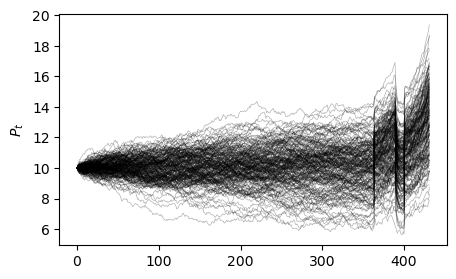

In [9]:
N = 200
all_series = pd.DataFrame()
seed = 5
np.random.seed(seed)

for i in range(N):
    Pf, B, P = simulation_master.simulate_price_with_bubbles(

        # Sample size
        T = 432,
        
        # Fundamental component
        rho_f = 1.0,
        mu_f = 0.00,
        sigma_f = 0.08,
        Pf0 = 10.0,

        # Bubble component
        include_bubble = True,
        R = 0.04,
        sigma_b = 0.1,
        omega = 0.6,
        B0 = 0.0,

        # Covid
        # tau_s1 = 360, 
        # tau_e1 = 384,
        # B0_1 = 0.6,
        tau_s1 = 364, 
        tau_e1 = 389,
        B0_1 = 0.6,

        # AI
        tau_s2 = 401,
        tau_e2 = 432,
        B0_2 = 1.0,

    )

    all_series[f"sim_{i+1}"] = P.values

all_series.to_csv("data/P_latebubbles_MC.csv", index=False)

# plot all series
plt.figure(figsize=(5, 3))
for col in all_series.columns:
    plt.plot(all_series.index, all_series[col], color='black', linewidth=0.5, alpha=0.3)
plt.ylabel(r'$P_t$')
plt.show()

### 5. Now we calculate the GSADF, SADF and ADF rejection rates for small and large sample

In [7]:
%%R
library(exuber)

# Load data
dat_full <- read.csv("data/P_latebubbles_MC.csv")

# Create short sample (301–432)
dat_short <- dat_full[301:432, ]

# Sample sizes
T_full  <- nrow(dat_full)
T_short <- nrow(dat_short)

# --------------------------
# FULL SAMPLE
# --------------------------
res_full <- radf(dat_full, lag = 0)
cv_full  <- radf_mc_cv(n = T_full, nrep = 2000, seed = 123)

reject_gsadf_full <- as.numeric(res_full$gsadf)        > cv_full$gsadf_cv[2]
reject_sadf_full  <- as.numeric(res_full$sadf)         > cv_full$sadf_cv[2]
reject_adf_full   <- as.numeric(res_full$adf)          > cv_full$adf_cv[2]

rej_rate_gsadf_full <- mean(reject_gsadf_full)
rej_rate_sadf_full  <- mean(reject_sadf_full)
rej_rate_adf_full   <- mean(reject_adf_full)

# --------------------------
# SHORT SAMPLE
# --------------------------
res_short <- radf(dat_short, lag = 0)
cv_short  <- radf_mc_cv(n = T_short, nrep = 2000, seed = 123)

reject_gsadf_short <- as.numeric(res_short$gsadf)        > cv_short$gsadf_cv[2]
reject_sadf_short  <- as.numeric(res_short$sadf)         > cv_short$sadf_cv[2]
reject_adf_short   <- as.numeric(res_short$adf)          > cv_short$adf_cv[2]

rej_rate_gsadf_short <- mean(reject_gsadf_short)
rej_rate_sadf_short  <- mean(reject_sadf_short)
rej_rate_adf_short   <- mean(reject_adf_short)

# --------------------------
# OUTPUT
# --------------------------
cat("\n===== FULL SAMPLE =====\n")
cat("GSADF rejection rate:", as.numeric(rej_rate_gsadf_full), "\n")
cat("SADF  rejection rate:", as.numeric(rej_rate_sadf_full),  "\n")
cat("ADF   rejection rate:", as.numeric(rej_rate_adf_full),   "\n")

cat("\n===== SHORT SAMPLE =====\n")
cat("GSADF rejection rate:", as.numeric(rej_rate_gsadf_short), "\n")
cat("SADF  rejection rate:", as.numeric(rej_rate_sadf_short),  "\n")
cat("ADF   rejection rate:", as.numeric(rej_rate_adf_short),   "\n")


===== FULL SAMPLE =====
GSADF rejection rate: 0.555 
SADF  rejection rate: 0.49 
ADF   rejection rate: 0.595 

===== SHORT SAMPLE =====
GSADF rejection rate: 0.5 
SADF  rejection rate: 0.65 
ADF   rejection rate: 0.695 
